In [4]:
from ultralytics import YOLO
from IPython.display import Image, display

In [4]:
model = YOLO("yolov8n.pt")

model.train(data="yolo_lab_images/data.yaml", epochs=50, imgsz=448)

Ultralytics 8.4.21 🚀 Python-3.11.14 torch-2.10.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_lab_images/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=448, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x13a39dc10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

After training, I evaluated the model on test images that it had never seen before. The detector performed well overall and correctly identified most objects.

Most errors were related to missed detections rather than incorrect classifications. The phone class appeared to be slightly more difficult for the model, and a few phones were not detected in some images. This may be because phones often blend into the background or appear at different angles.

Bounding boxes were generally accurate, although in some cases they were slightly larger than the object. Overall, the results show that the model performs reliably but could improve with a larger and more diverse dataset.

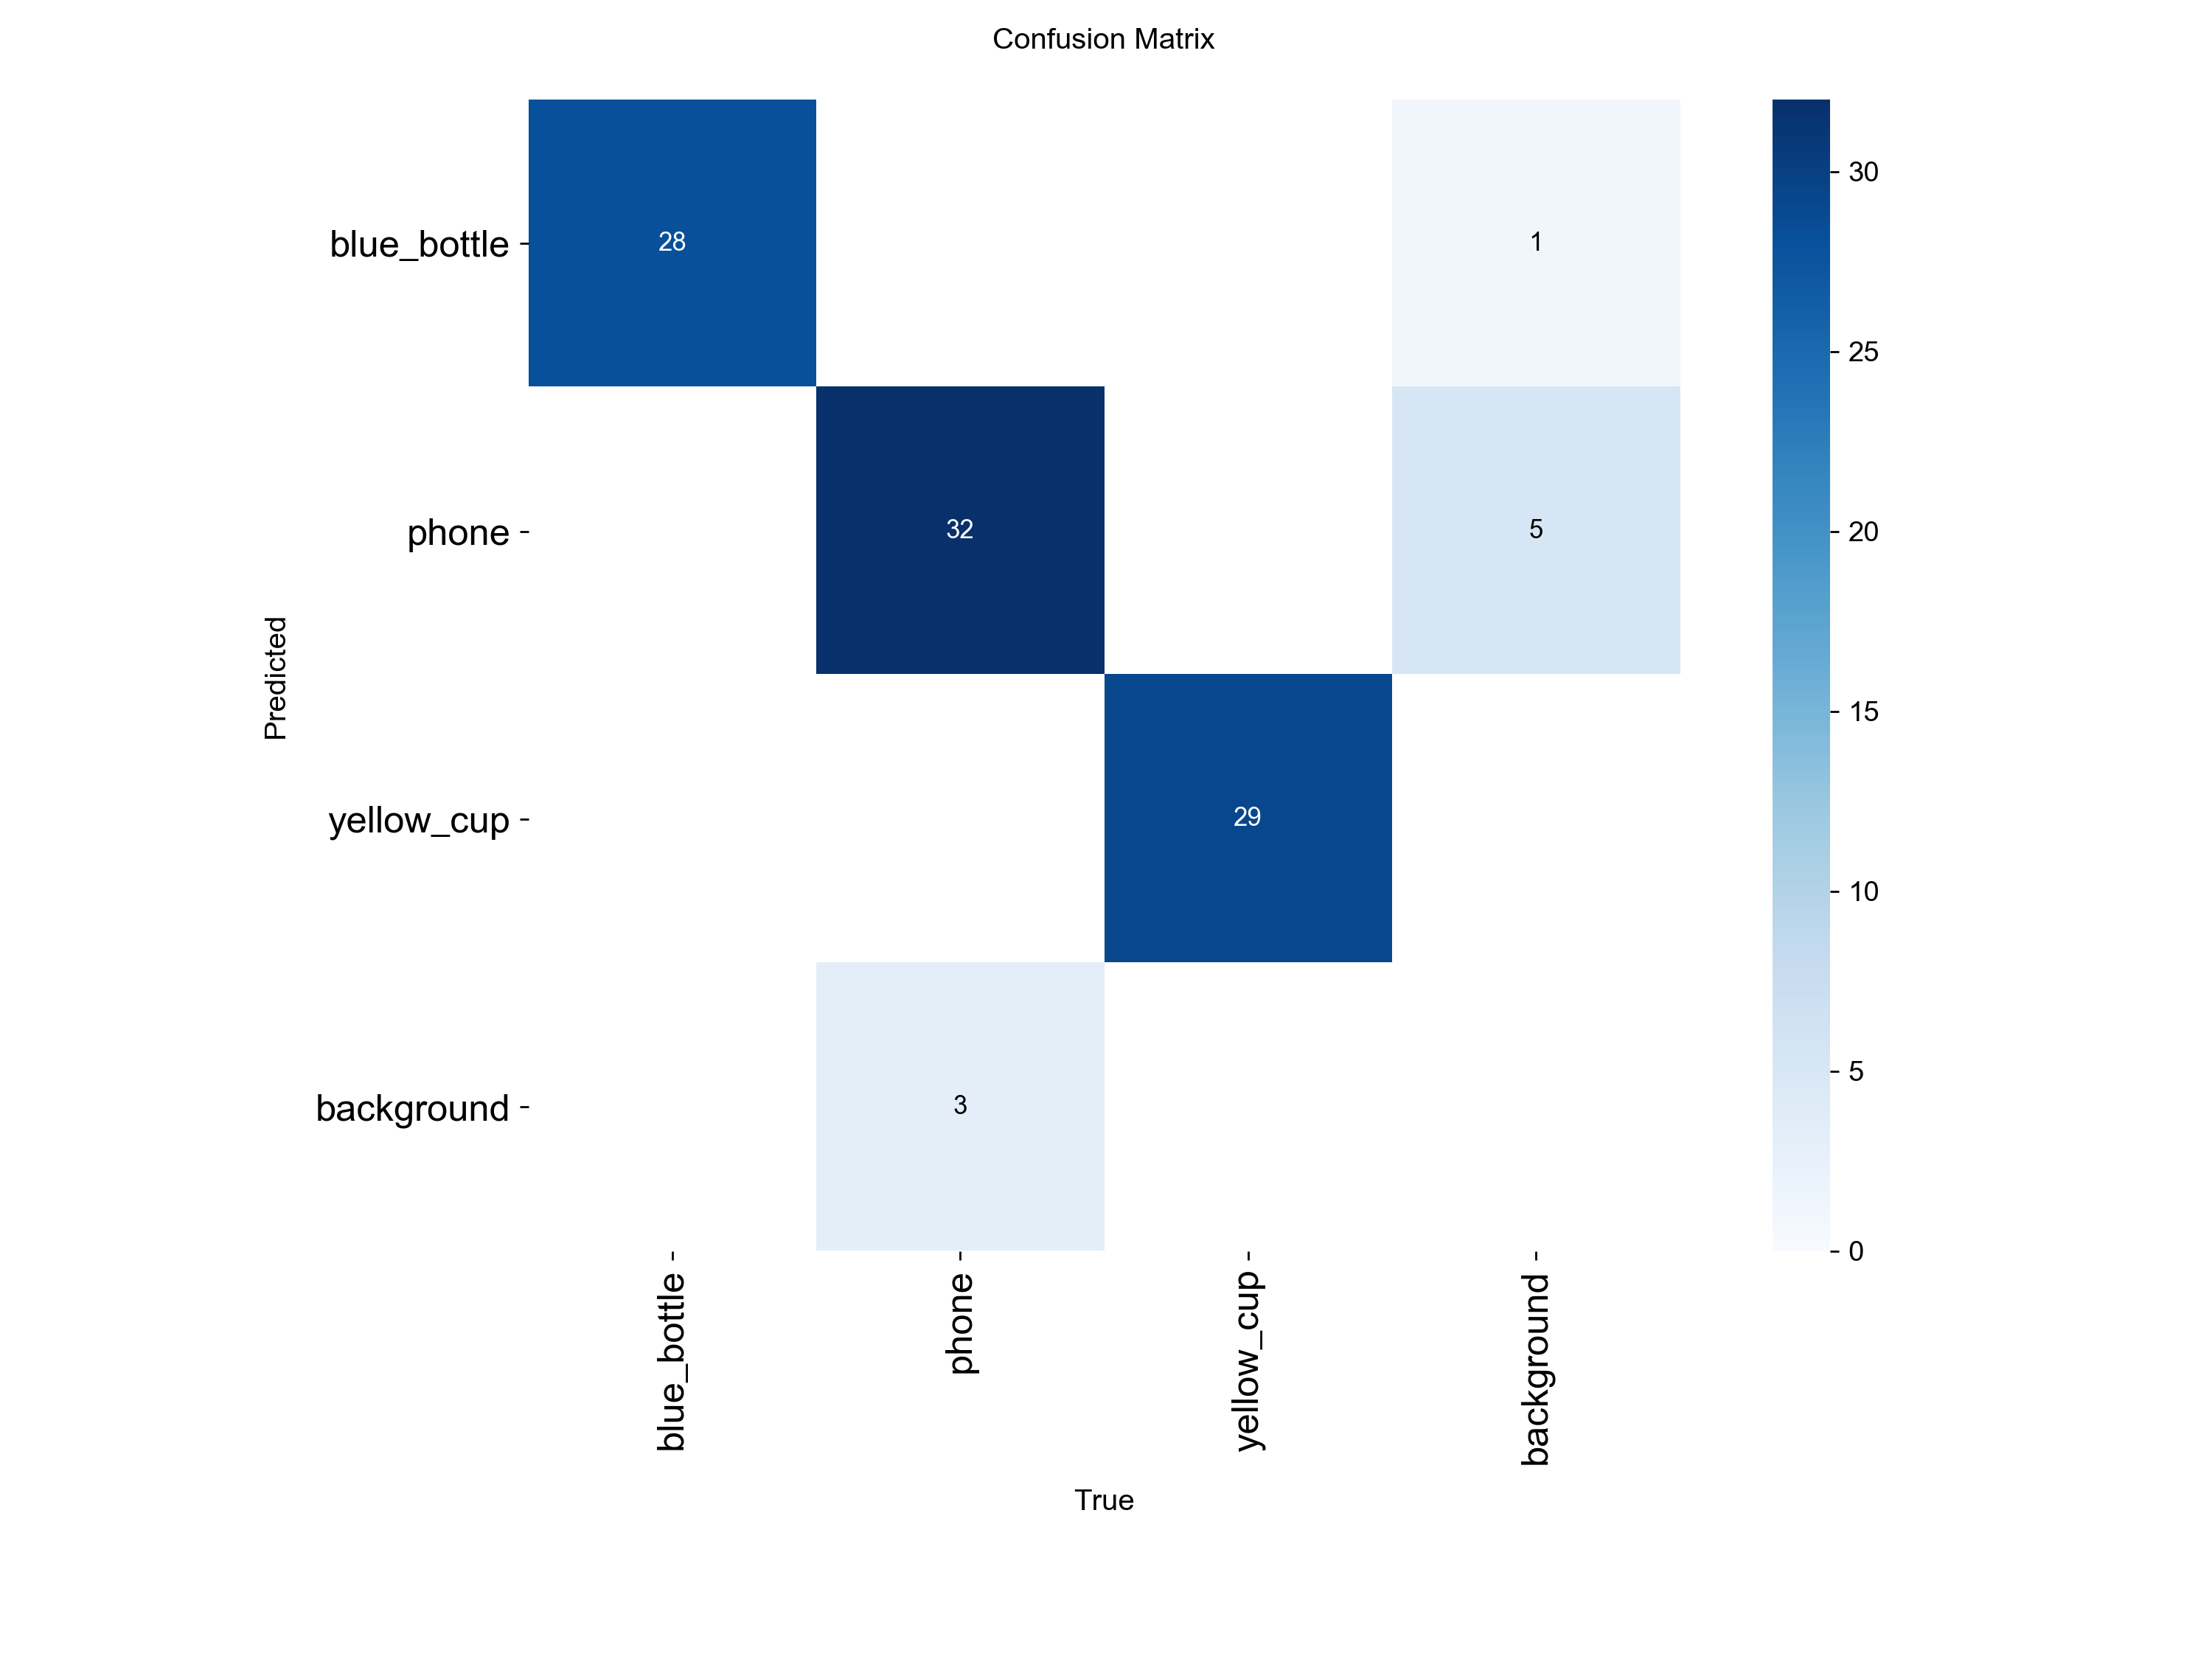

In [5]:
display(Image("runs/detect/train/confusion_matrix.png"))

In [5]:
model.val(data="yolo_lab_images/data.yaml", split="test")

Ultralytics 8.4.21 🚀 Python-3.11.14 torch-2.10.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 158.2±72.1 MB/s, size: 47.2 KB)
val: Scanning /Users/katya/PycharmProjects/Lexicon/yolo_project/yolo_lab_images/test/labels... 22 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 22/22 1.3Kit/s 0.0s
val: New cache created: /Users/katya/PycharmProjects/Lexicon/yolo_project/yolo_lab_images/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6it/s 1.3s3.6s
                   all         22         42      0.973      0.961      0.988      0.749
           blue_bottle         12         12       0.97          1      0.995       0.78
                 phone         14         17      0.991      0.882      0.973      0.662
            yellow_cup         13         13      0.959          1      0.995      0.805
Speed: 0.7m

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x14c03a750>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

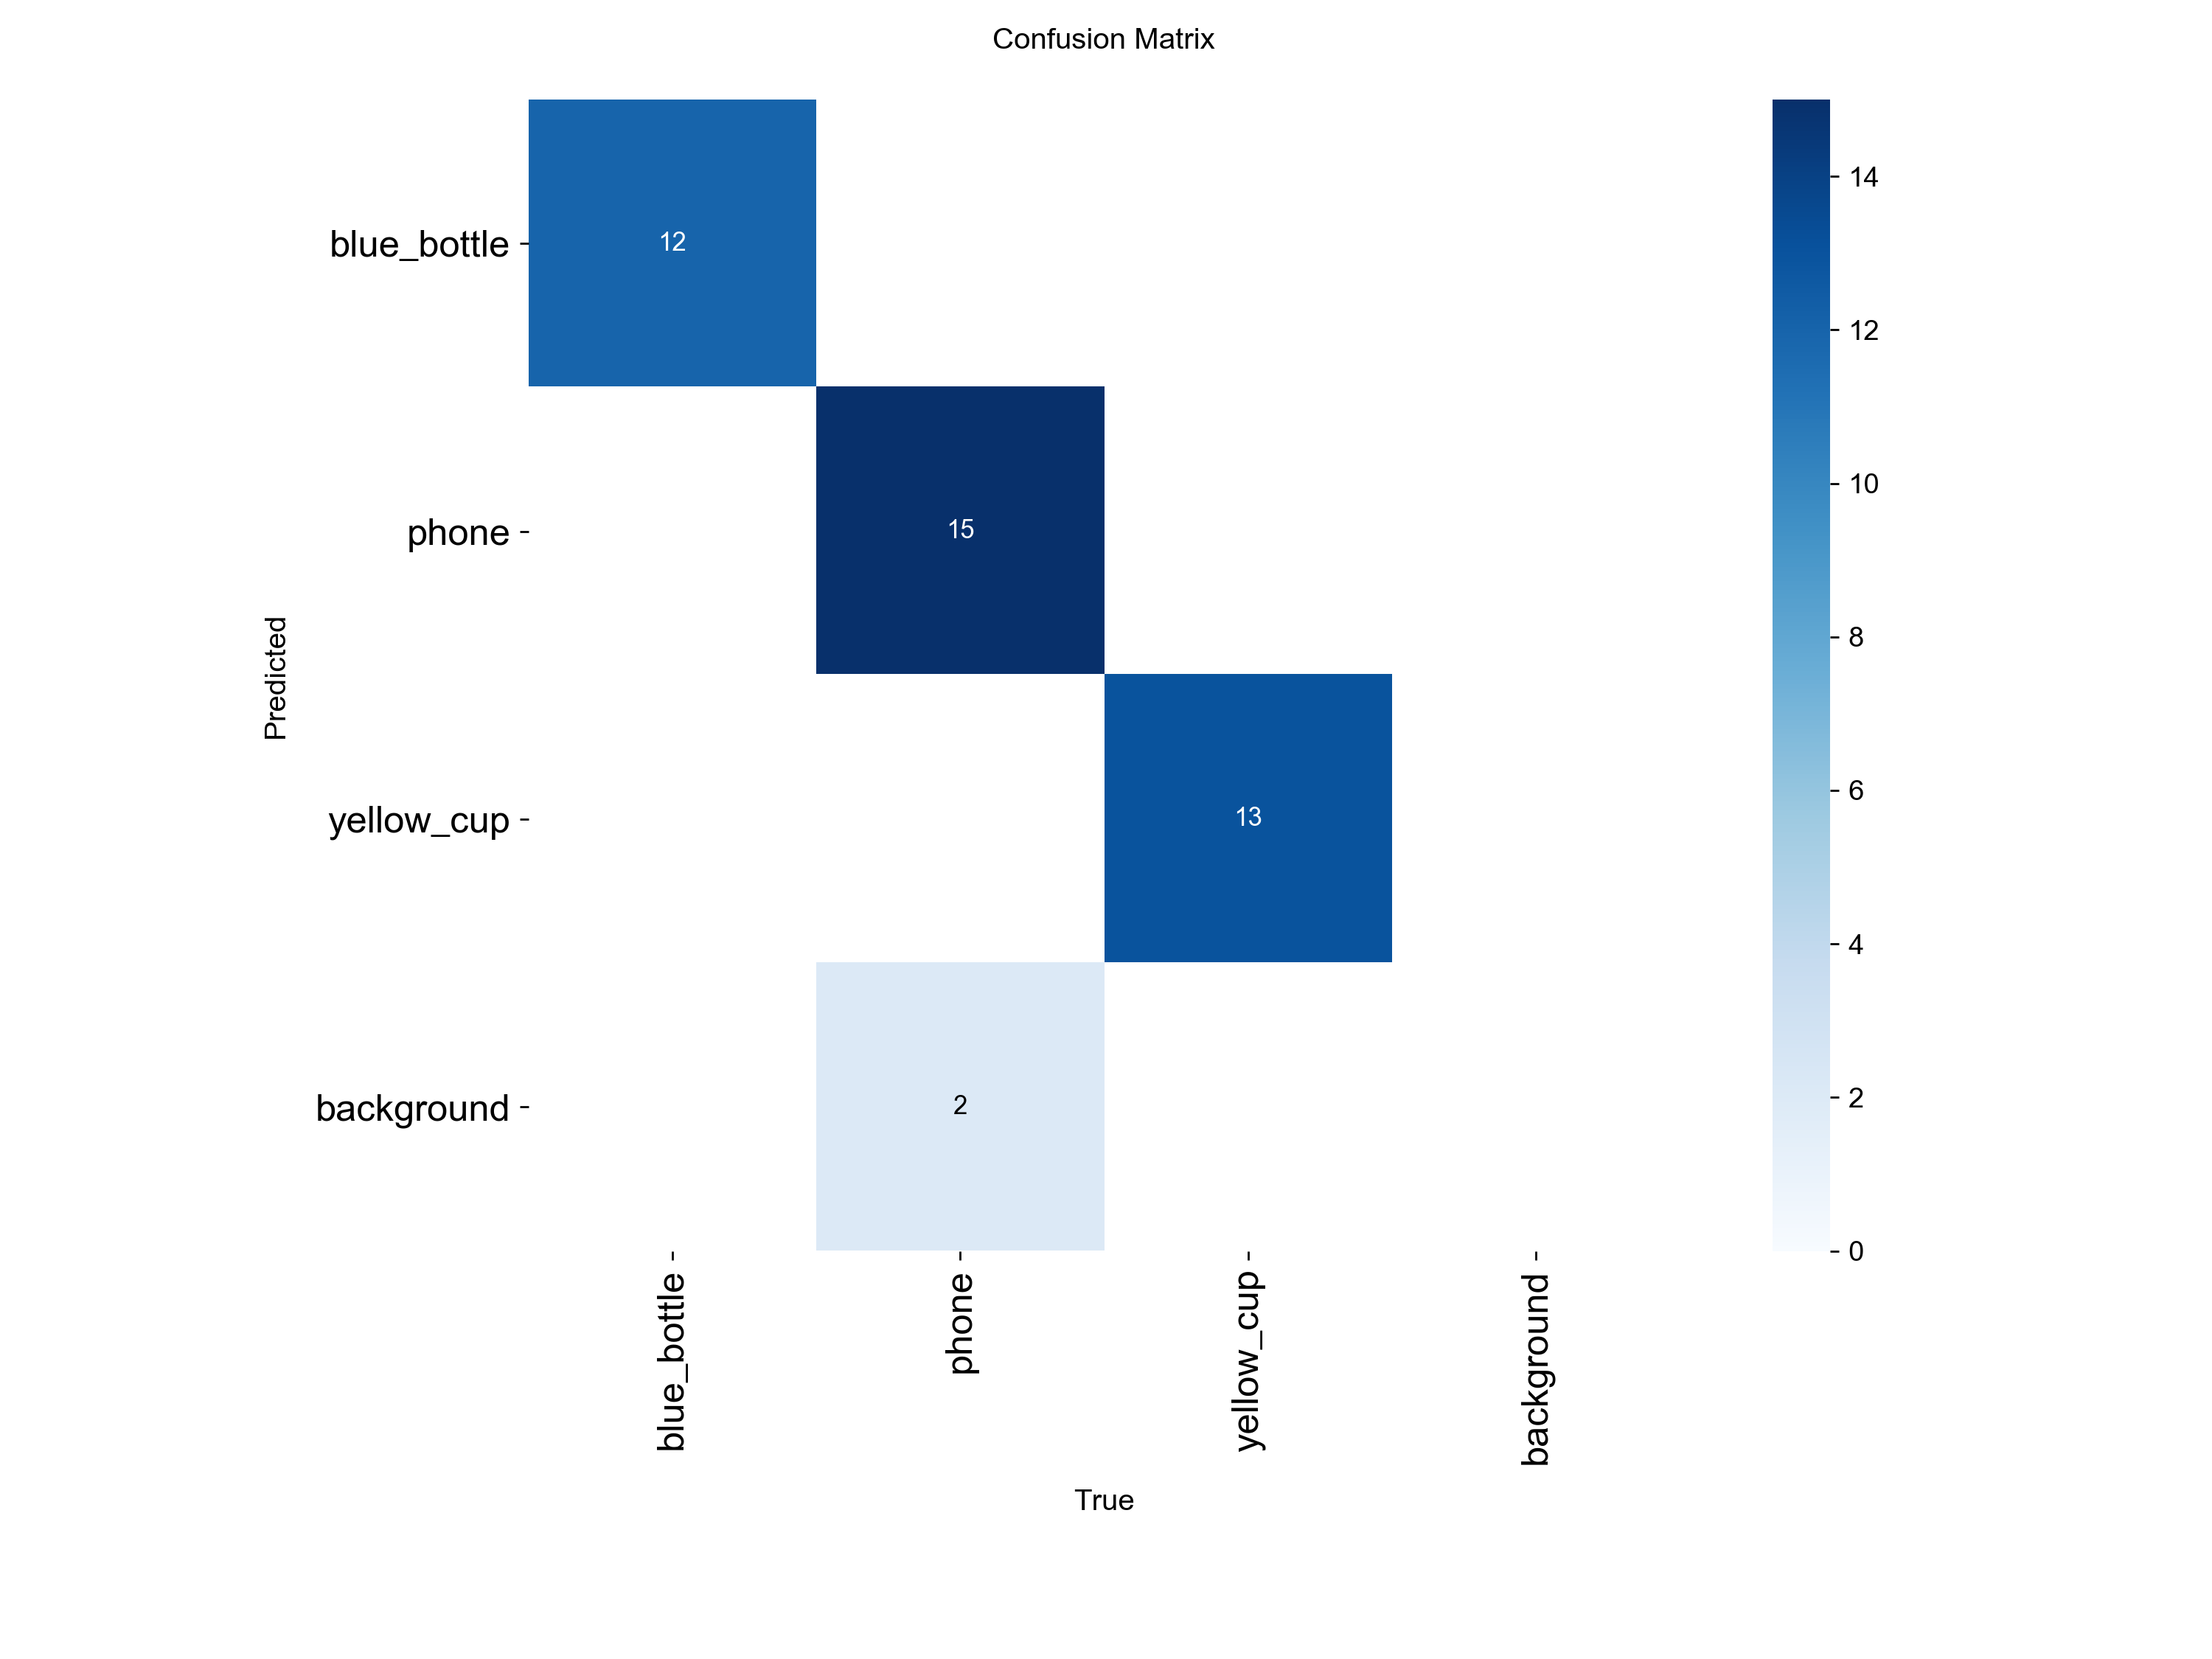

In [6]:
display(Image("runs/detect/val/confusion_matrix.png"))

In [3]:
best_model = YOLO("runs/detect/train/weights/best.pt")
results = best_model.predict(source=0, stream=True, show=True)

for r in results:
    pass

2026-03-11 15:11:48.257 python[2335:32034] WARNING: AVCaptureDeviceTypeExternal is deprecated for Continuity Cameras. Please use AVCaptureDeviceTypeContinuityCamera and add NSCameraUseContinuityCameraDeviceType to your Info.plist.


1/1: 0... Success ✅ (inf frames of shape 1920x1080 at 15.00 FPS)

0: 256x448 (no detections), 41.3ms
0: 256x448 (no detections), 21.4ms
0: 256x448 (no detections), 22.2ms
0: 256x448 (no detections), 16.3ms
0: 256x448 (no detections), 17.5ms


2026-03-11 15:11:49.305 python[2335:32034] +[IMKClient subclass]: chose IMKClient_Modern
2026-03-11 15:11:49.305 python[2335:32034] +[IMKInputSession subclass]: chose IMKInputSession_Modern


0: 256x448 1 blue_bottle, 18.5ms
0: 256x448 1 blue_bottle, 17.2ms
0: 256x448 1 blue_bottle, 16.0ms
0: 256x448 1 blue_bottle, 17.7ms
0: 256x448 1 blue_bottle, 17.6ms
0: 256x448 1 blue_bottle, 17.4ms
0: 256x448 1 blue_bottle, 14.8ms
0: 256x448 1 blue_bottle, 14.8ms
0: 256x448 1 blue_bottle, 15.7ms
0: 256x448 1 blue_bottle, 14.1ms
0: 256x448 1 blue_bottle, 14.7ms
0: 256x448 1 blue_bottle, 18.0ms
0: 256x448 1 blue_bottle, 16.1ms
0: 256x448 1 blue_bottle, 15.8ms
0: 256x448 1 blue_bottle, 19.2ms
0: 256x448 1 blue_bottle, 16.6ms
0: 256x448 1 blue_bottle, 15.7ms
0: 256x448 1 blue_bottle, 16.0ms
0: 256x448 1 blue_bottle, 14.8ms
0: 256x448 2 blue_bottles, 14.4ms
0: 256x448 2 blue_bottles, 14.5ms
0: 256x448 1 blue_bottle, 13.7ms
0: 256x448 1 blue_bottle, 15.1ms
0: 256x448 1 blue_bottle, 14.1ms
0: 256x448 1 blue_bottle, 14.3ms
0: 256x448 1 blue_bottle, 14.1ms
0: 256x448 1 blue_bottle, 14.5ms
0: 256x448 1 blue_bottle, 14.6ms
0: 256x448 1 blue_bottle, 14.1ms
0: 256x448 1 blue_bottle, 14.2ms
0: 256x4

KeyboardInterrupt: 